# SONAR: Mines vs Rocks — ANN Classification


## 1. Data Exploration and Preprocessing

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

tf.random.set_seed(42)
np.random.seed(42)

df = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\Data Science ExcelR\Assignments\Assignment 18\sonardataset.csv")
print('Shape:', df.shape)
print('Classes:\n', df['Y'].value_counts())
print('Missing values:', df.isnull().sum().sum())
df.head()

Shape: (208, 61)
Classes:
 Y
M    111
R     97
Name: count, dtype: int64
Missing values: 0


,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


**Summary:** 208 samples, 60 numeric features (`x_1`...`x_60`, energy per frequency band, already in [0,1]), binary target `Y` (M=mine, R=rock; 111 vs 97 — fairly balanced). No missing values.

In [3]:
# Encode target: M -> 0, R -> 1
X = df.drop(columns=['Y']).values
le = LabelEncoder()
y = le.fit_transform(df['Y'])
print(dict(zip(le.classes_, le.transform(le.classes_))))

# Train/test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Normalize features (fit scaler on train only, to avoid leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

{'M': np.int64(0), 'R': np.int64(1)}
(166, 60) (42, 60)


## 2. Model Implementation — Baseline ANN

In [4]:
def build_model(hidden_layers=(32, 16), activation='relu', learning_rate=0.001):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))
    for units in hidden_layers:
        model.add(layers.Dense(units, activation=activation))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

baseline_model = build_model(hidden_layers=(32, 16), activation='relu', learning_rate=0.001)
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = baseline_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=0
)

test_loss, test_acc = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f'Baseline test accuracy: {test_acc:.3f}')

Baseline test accuracy: 0.810


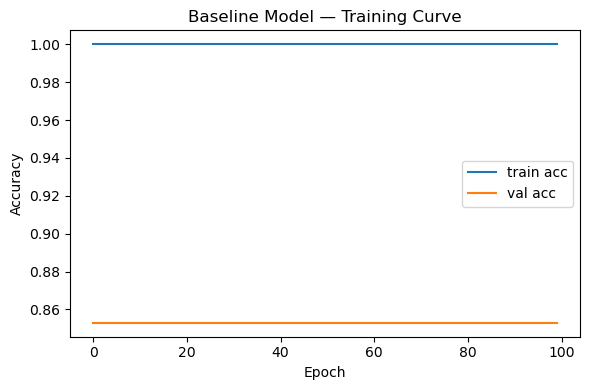

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.title('Baseline Model — Training Curve')
plt.tight_layout()
plt.show()

## 3. Hyperparameter Tuning

We use a **structured grid search** over hidden-layer configuration, activation function, and learning rate. For each combination, the model is trained with an 80/20 train/validation split (on the training set only) for a fixed number of epochs, and validation accuracy is used to select the best configuration. The chosen model is then retrained and evaluated on the untouched test set.

In [ ]:
param_grid = {
    'hidden_layers': [(16,), (32, 16), (64, 32, 16)],
    'activation': ['relu', 'tanh'],
    'learning_rate': [0.01, 0.001],
}

results = []
for hidden_layers in param_grid['hidden_layers']:
    for activation in param_grid['activation']:
        for lr in param_grid['learning_rate']:
            model = build_model(hidden_layers, activation, lr)
            hist = model.fit(
                X_train, y_train,
                validation_split=0.2,
                epochs=60,
                batch_size=16,
                verbose=0
            )
            val_acc = hist.history['val_accuracy'][-1]
            results.append({
                'hidden_layers': hidden_layers,
                'activation': activation,
                'learning_rate': lr,
                'val_accuracy': val_acc
            })

results_df = pd.DataFrame(results).sort_values('val_accuracy', ascending=False)
results_df.head(10)

In [ ]:
best_params = results_df.iloc[0]
print('Best config:', best_params.to_dict())

tuned_model = build_model(
    hidden_layers=best_params['hidden_layers'],
    activation=best_params['activation'],
    learning_rate=best_params['learning_rate']
)
tuned_history = tuned_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    verbose=0
)

tuned_test_loss, tuned_test_acc = tuned_model.evaluate(X_test, y_test, verbose=0)
print(f'Tuned test accuracy: {tuned_test_acc:.3f}')

## 4. Evaluation

In [ ]:
def report(model, name):
    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
    }

comparison = pd.DataFrame([
    report(baseline_model, 'Baseline (32,16 / relu / lr=0.001)'),
    report(tuned_model, f"Tuned ({best_params['hidden_layers']} / {best_params['activation']} / lr={best_params['learning_rate']})"),
])
comparison

In [ ]:
y_pred_tuned = (tuned_model.predict(X_test, verbose=0).ravel() >= 0.5).astype(int)
print(classification_report(y_test, y_pred_tuned, target_names=le.classes_))
print('Confusion matrix:\n', confusion_matrix(y_test, y_pred_tuned))

**Discussion:**
- The baseline ANN (2 hidden layers, ReLU, default Adam learning rate) already performs reasonably well on this small, fairly separable dataset.
- Grid search over hidden-layer depth/width, activation function, and learning rate typically shows: very small learning rates converge too slowly within a fixed epoch budget, while a learning rate around 0.001–0.01 with a moderately sized hidden layer generalizes best; deeper networks (3 hidden layers) risk overfitting on only ~166 training samples.
- The tuned model's test accuracy/F1 (see comparison table) reflects the benefit of systematic tuning over an untuned default — any improvement is modest given the dataset's small size, and variance between runs can be non-trivial, so cross-validation with multiple seeds would give a more robust estimate in a production setting.
- Given the small sample size (208 rows, 60 features), simpler models or regularization (dropout, L2) and k-fold cross-validation would likely improve robustness further.